Some typical NumPy 'random' functions:

In [ ]:
import numpy as np

# To generate a random float values between 0 and 1 (exclusive)
print(np.random.rand(3, 2)) # Creates a 3 x 2 matrix of random float values between 0 and 1 (exclusive)

# To generate random float values from standard normal distribution (mean = 0 and std = 1)
print(np.random.randn(5)) # Generates 5 random float values from standard normal distribution

# To generate random integer values within a range of values
print(np.random.randint(1, 100, 10)) # Generates 10 random integer values between 1 and 100 (exclusive)

# To randomly select an element from a given list of elements
print(np.random.choice([1, 2, 3, 4, 5, 6, 7, 8, 9], size=3)) # Three random numbers from the given array will be chosen

# To generate a random sample of values from a normally distributed with a specified mean and standard deviation
print(np.random.normal(loc=0, scale=1, size=10)) # 10 random values will be generated from a normally distributed data where 0 (loc) is the mean and 1 (scale) is the standard deviation

# To set a seed for a random number generation to ensure you get the same results later as well
print(np.random.seed(42)) # This ensures that any random numbers generated in the program are same every time you run the program. The seed value '42' can be any other value

AIM #1: Generate a very large dataset
1. Generate a dataset of 1 million random data items between 1 and 100 items using only pandas
2. Generate a dataset of 1 million random data items between 1 and 100 using only NumPy
3. Calculate the time it takes for both the above operations. 
    3.1. Import the 'time' module, and use the time() function to calculate current time
    3.2. Which one is faster and why?

In [1]:
# Write your code for AIM #1 here
import pandas as pd
import time
import numpy as np

# Start time
start_time = time.time()

# Generate 1 million random integers between 1 and 100 using pandas and NumPy
df = pd.DataFrame({'Random_Data': np.random.randint(1, 101, 1000000)})

# End time
end_time = time.time()

# Calculate time taken
print(f"Time taken by pandas: {end_time - start_time} seconds")

# Start time
start_time = time.time()

# Generate 1 million random integers between 1 and 100 using NumPy
arr = np.random.randint(1, 101, 1000000)

# End time
end_time = time.time()

# Calculate time taken
print(f"Time taken by NumPy: {end_time - start_time} seconds")



#In general, NumPy usually performs faster than pandas for the following reasons:

#The underlying implementation:

#NumPy is based on a C and Fortran implementation optimized specifically for numerical computation, which provides higher performance.
#pandas is in many cases built on top of NumPy, but it adds additional features and data structures (such as DataFrame) that introduce some overhead.
#Memory management:

#NumPy uses contiguous blocks of memory to store data, which makes access faster, especially when working with large data sets.
#pandas needs to manage more complex data structures, so it may be slower when working with large amounts of data.
#Functionality Extension:

#pandas offers a number of features such as data analysis and processing capabilities that, while powerful, can lead to performance degradation.

#Translated with DeepL.com (free version)


Time taken by pandas: 0.007001161575317383 seconds
Time taken by NumPy: 0.006000995635986328 seconds


AIM #2: Basic statistics
For the given dataset on sleep health and lifestyle, do the following
1. Using only pandas, load the dataset, calculate mean 'Sleep Duration', 'Systolic Blood Pressure', 'Diastolic Blood Pressure', 'Heart Rate' and 'Daily Steps'.
2. Do the same as in Step 1 using only NumPy
3. Using only pandas, first calculate correlation (across only the numerical variables), and then separate correlation between...
    Sleep duration and Age
    Sleep duration and Heart rate
    Sleep duration and Daily steps
4. Using only NumPy, do the same as Step 3
5. Using pandas only, calculate standard deviation for 'Sleep Duration'. 
6. Usiong NumPy only, calculate standard deviation for 'Sleep Duration'. 
7. Calculate the time difference between using pandas and NumPy, right from the step of loading the dataset to the final standard deviation step. 
    5.1. Which one is faster and why?

In [2]:
# Write your code for AIM #2 here
import pandas as pd
import numpy as np
import time

# Load the dataset
df = pd.read_csv('sleep_health.csv')

# Convert all non-numeric columns to category type to avoid errors
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].astype('category')

# Step 1: Using pandas to calculate the mean
start_time_pandas = time.time()
mean_values = df[['Sleep Duration', 'Systolic blood pressure', 'Diastolic blood pressure', 'Heart Rate', 'Daily Steps']].mean()
print("Pandas Mean Calculation:")
print(mean_values)
end_time_pandas = time.time()

# Step 2: Using NumPy to calculate the mean
start_time_numpy = time.time()
mean_values_np = df[['Sleep Duration', 'Systolic blood pressure', 'Diastolic blood pressure', 'Heart Rate', 'Daily Steps']].values.mean(axis=0)
print("NumPy Mean Calculation:")
print(mean_values_np)
end_time_numpy = time.time()

# Step 3: Using pandas to calculate correlation
start_time_pandas_corr = time.time()
# Select only numerical columns for correlation
numerical_df = df.select_dtypes(include=[np.number])
correlation_matrix = numerical_df.corr()
print("Pandas Correlation Matrix:")
print(correlation_matrix)

# Separate correlations
corr_sleep_duration_age = correlation_matrix['Sleep Duration']['Age']
corr_sleep_duration_heart_rate = correlation_matrix['Sleep Duration']['Heart Rate']
corr_sleep_duration_daily_steps = correlation_matrix['Sleep Duration']['Daily Steps']
print("Pandas Correlation Calculations:")
print(f"Correlation Sleep Duration & Age: {corr_sleep_duration_age}")
print(f"Correlation Sleep Duration & Heart Rate: {corr_sleep_duration_heart_rate}")
print(f"Correlation Sleep Duration & Daily Steps: {corr_sleep_duration_daily_steps}")
end_time_pandas_corr = time.time()

# Step 4: Using NumPy to calculate correlation
start_time_numpy_corr = time.time()
data = df.select_dtypes(include=[np.number])[['Sleep Duration', 'Age', 'Heart Rate', 'Daily Steps']].values
corr_sleep_duration_age_np = np.corrcoef(data[:, 0], data[:, 1])[0, 1]
corr_sleep_duration_heart_rate_np = np.corrcoef(data[:, 0], data[:, 2])[0, 1]
corr_sleep_duration_daily_steps_np = np.corrcoef(data[:, 0], data[:, 3])[0, 1]
print("NumPy Correlation Calculations:")
print(f"Correlation Sleep Duration & Age: {corr_sleep_duration_age_np}")
print(f"Correlation Sleep Duration & Heart Rate: {corr_sleep_duration_heart_rate_np}")
print(f"Correlation Sleep Duration & Daily Steps: {corr_sleep_duration_daily_steps_np}")
end_time_numpy_corr = time.time()

# Step 5: Using pandas to calculate standard deviation
std_sleep_duration_pandas = df['Sleep Duration'].std()
print(f"Pandas Standard Deviation Sleep Duration: {std_sleep_duration_pandas}")

# Step 6: Using NumPy to calculate standard deviation
std_sleep_duration_np = np.std(df['Sleep Duration'].values)
print(f"NumPy Standard Deviation Sleep Duration: {std_sleep_duration_np}")

# Step 7: Calculate the time difference
print("Time difference (Pandas vs NumPy):")
print(f"Pandas Mean Time: {end_time_pandas - start_time_pandas} seconds")
print(f"NumPy Mean Time: {end_time_numpy - start_time_numpy} seconds")
print(f"Pandas Correlation Time: {end_time_pandas_corr - start_time_pandas_corr} seconds")
print(f"NumPy Correlation Time: {end_time_numpy_corr - start_time_numpy_corr} seconds")



Pandas Mean Calculation:
Sleep Duration                 7.132086
Systolic blood pressure      128.553476
Diastolic blood pressure      84.649733
Heart Rate                    70.165775
Daily Steps                 6816.844920
dtype: float64
NumPy Mean Calculation:
[   7.13208556  128.55347594   84.64973262   70.1657754  6816.84491979]
Pandas Correlation Matrix:
                          Person ID       Age  Sleep Duration  \
Person ID                  1.000000  0.990516        0.296305   
Age                        0.990516  1.000000        0.344709   
Sleep Duration             0.296305  0.344709        1.000000   
Quality of Sleep           0.431612  0.473734        0.883213   
Physical Activity Level    0.149882  0.178993        0.212360   
Stress Level              -0.394287 -0.422344       -0.811023   
Systolic blood pressure    0.611551  0.605878       -0.180406   
Diastolic blood pressure   0.590670  0.593839       -0.166570   
Heart Rate                -0.225467 -0.225606       

AIM #3: Use suitable plots to visualize the data

1. Using only pandas (and matplotlib/seaborn if necessary) plot the distribution for
    1.1. Age
    1.2. Sleep Duration
    1.3. Quality of Sleep
    1.4. Physical Activity Level
    1.5. Stress Level
    1.6. Heart Rate
2. Using only NumPy, do the same as Step 1. You will need matplotlib for this
3. Using only pandas, use the appropriate plot to
    3.1. See the distribution of 'Sleep Duration' based on 'Quality of Sleep'
    3.2. See the distribution of 'Sleep Duration' based on 'Stress Level'
    3.3. See the distribution of 'Sleep Duration' based on 'Physical Activity Level'
    3.4. See the distribution of 'Sleep Duration' based on 'Occupation'
    3.5. See the distribution of 'Sleep Duration' based on 'BMI'
4. Using only NumPy, do the same as Step 3. You will need matplotlib for this
5. Using only pandas, use a suitable plot to see the relation between
    5.1. Age and Sleep Duration
    5.2. Sleep Duration and Heart Rate
    5.3. Heart Rate and Daily Steps
    5.4. Sleep Duration and Daily Steps
6. Using only NumPy, do the same as Step 5. You will need matplotlib for this 
7. Find the time difference between plotting using only pandas, and plotting using NumPy

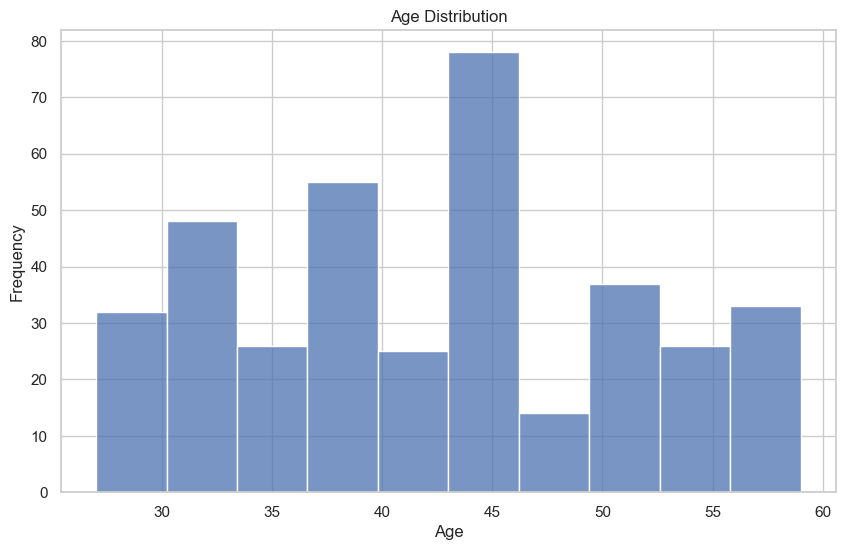

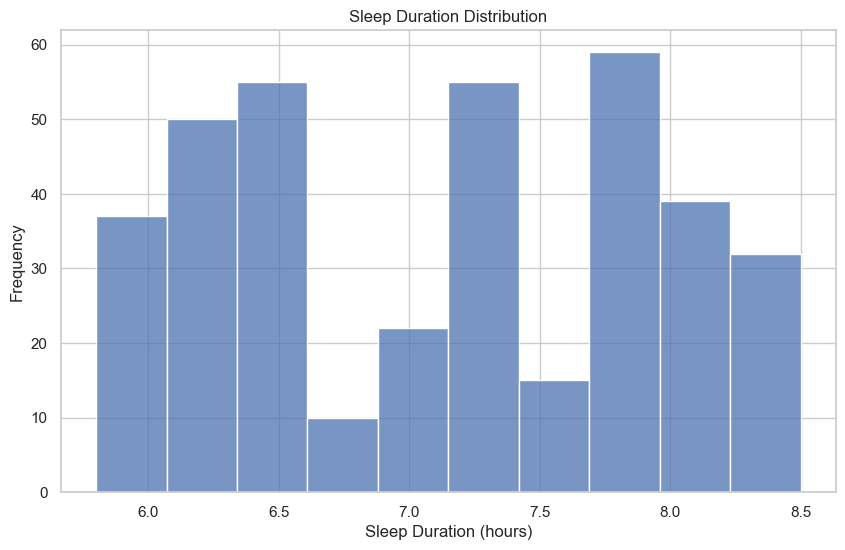

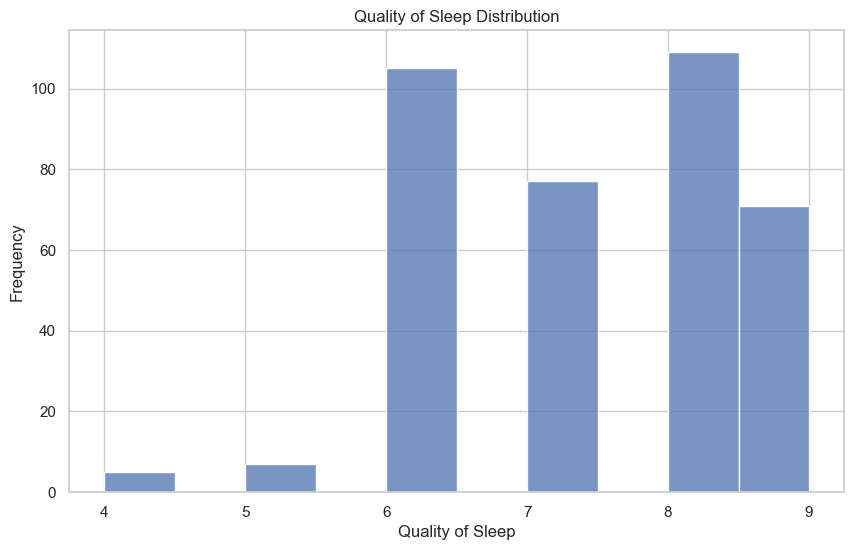

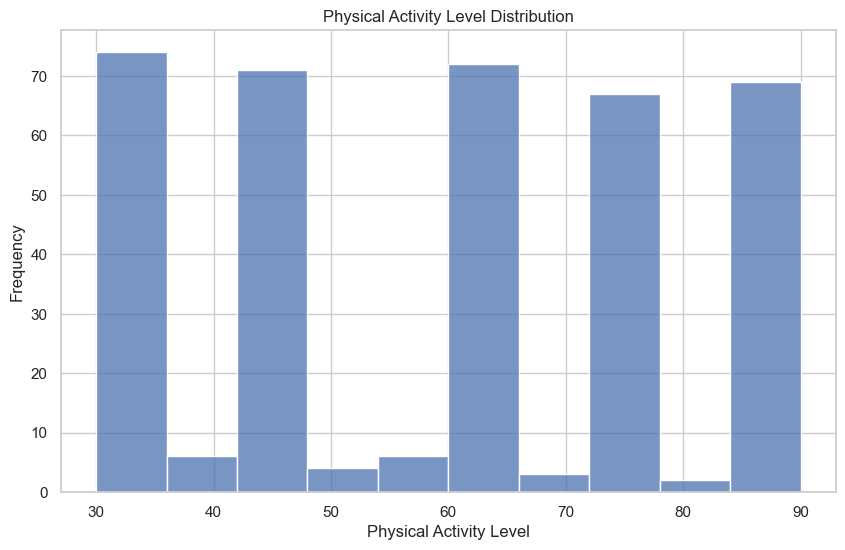

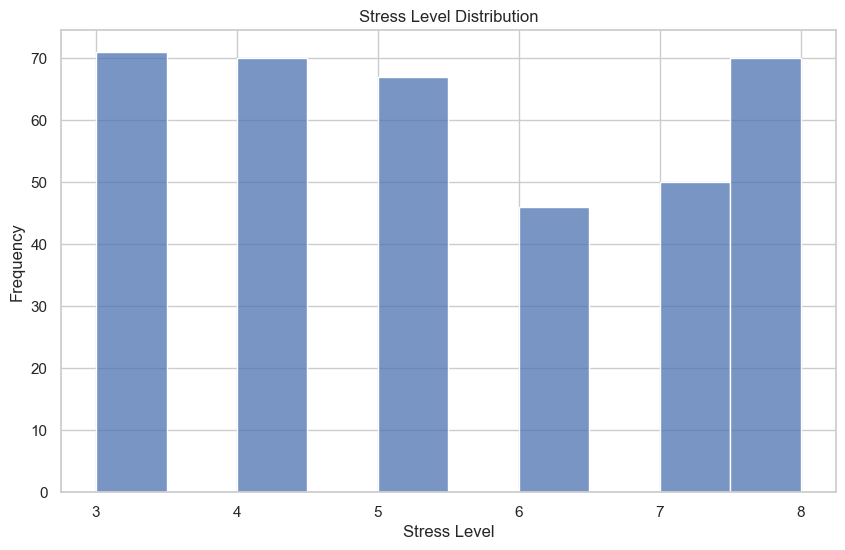

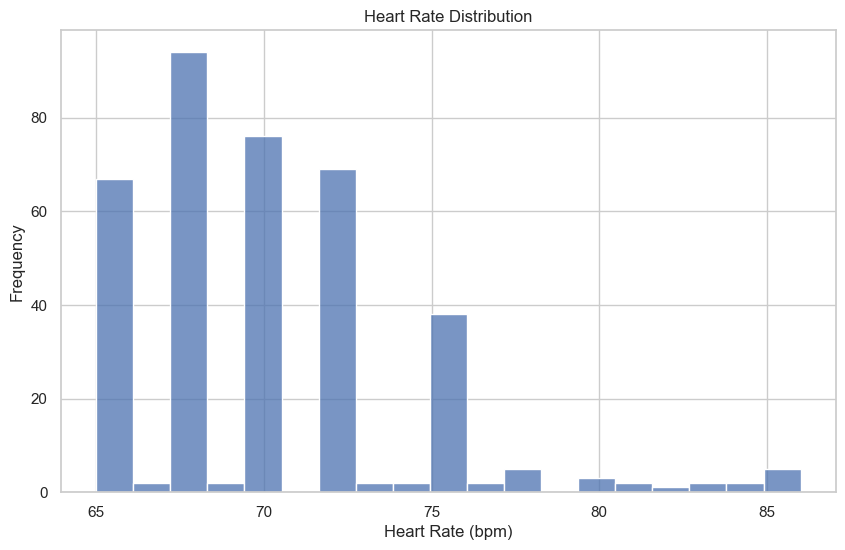

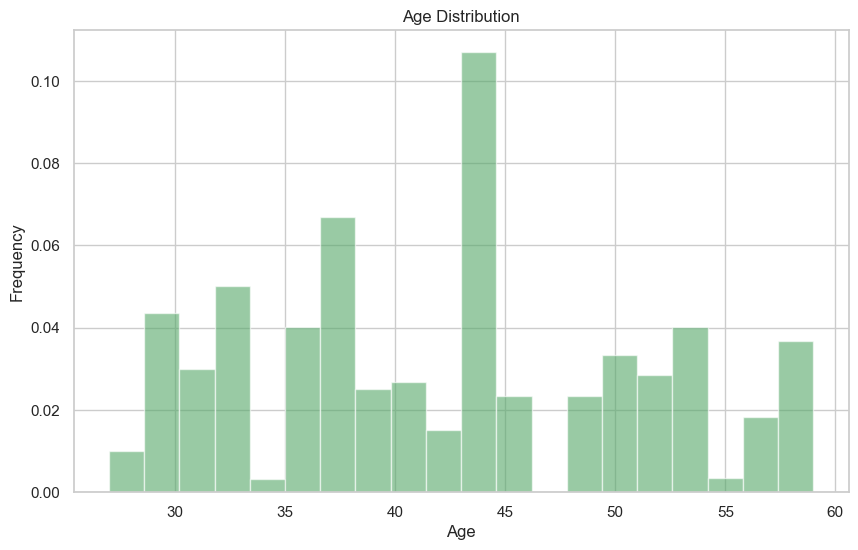

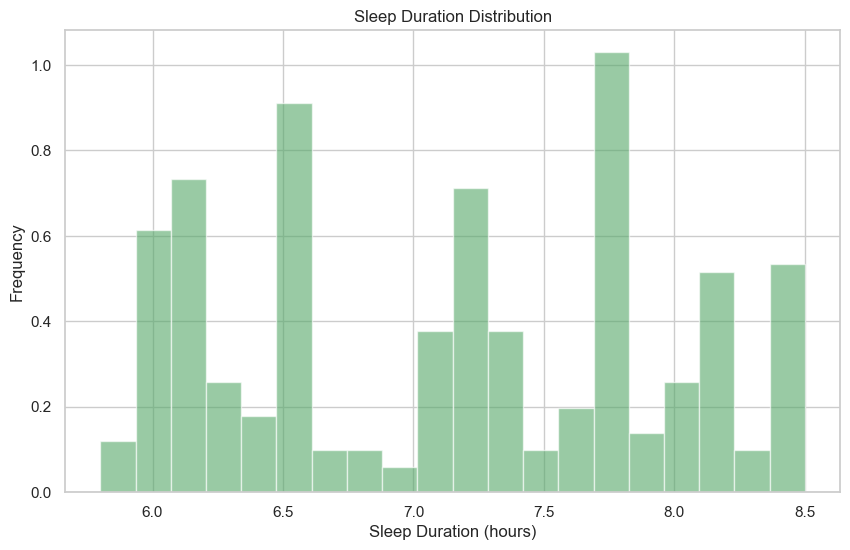

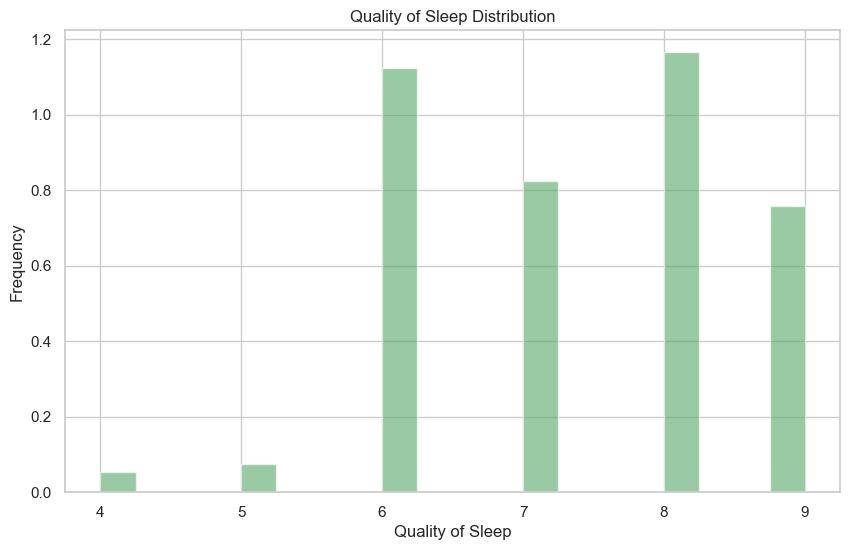

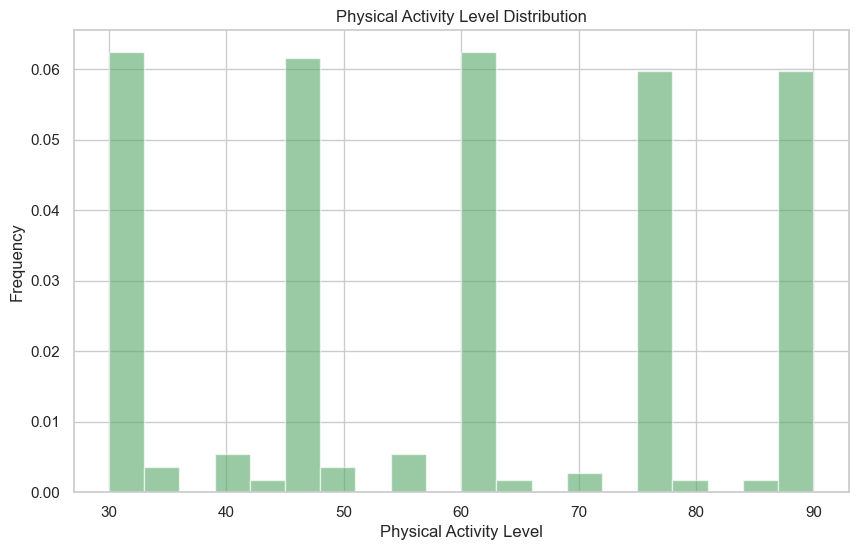

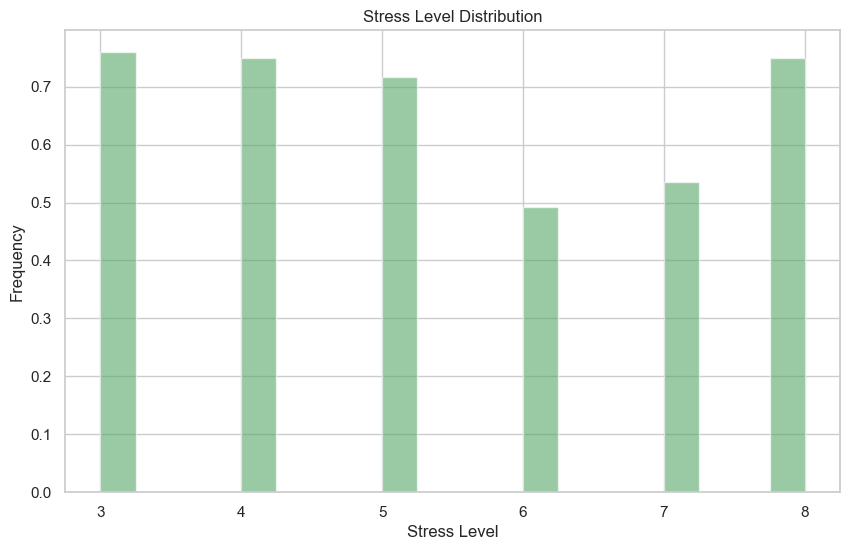

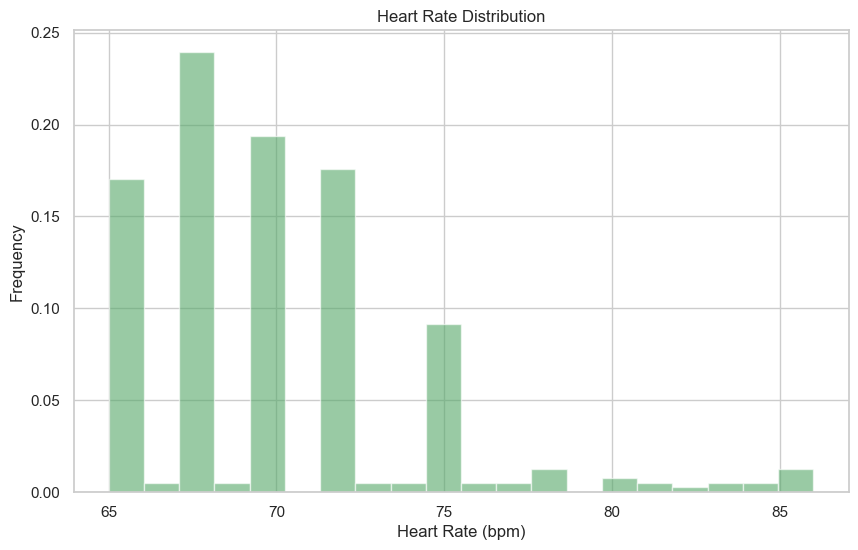

Pandas plotting time: 0.7705976963043213 seconds
NumPy plotting time: 0.7157566547393799 seconds


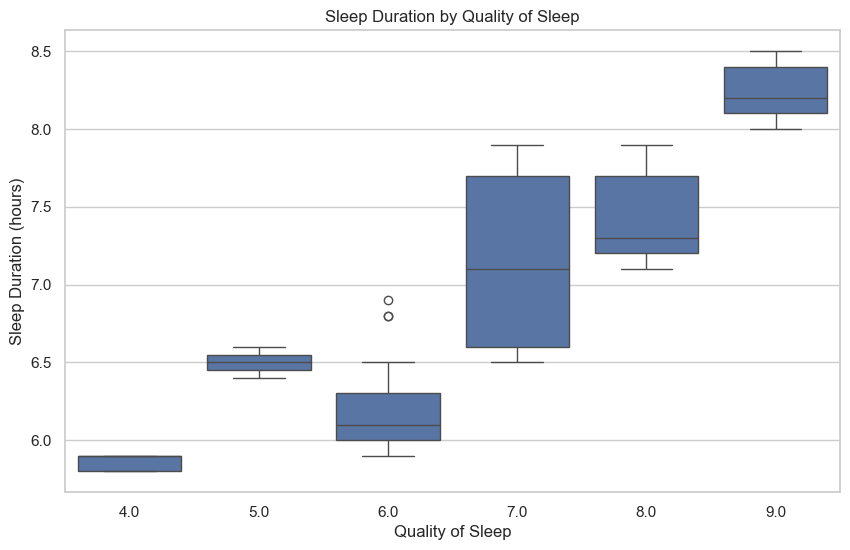

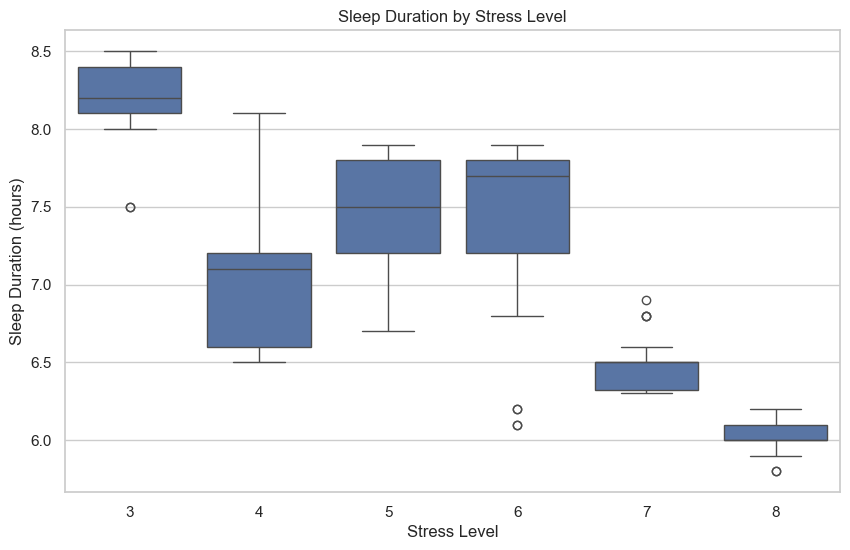

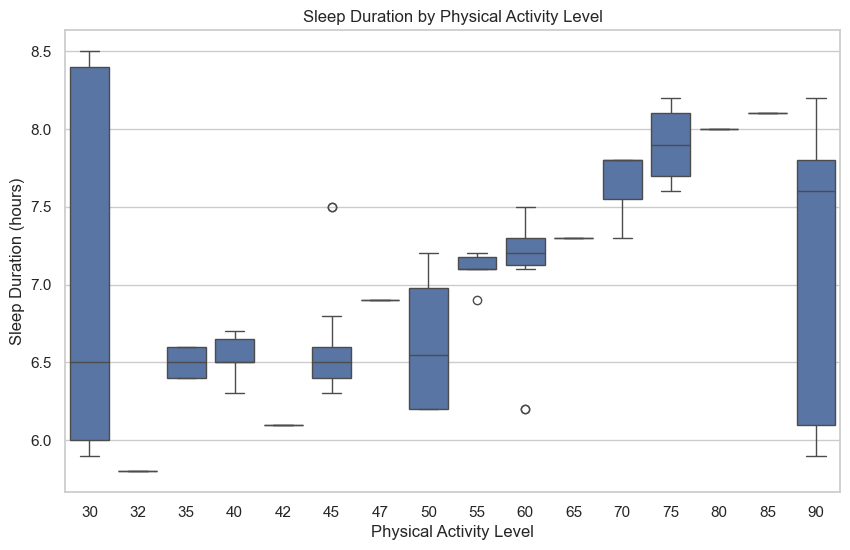

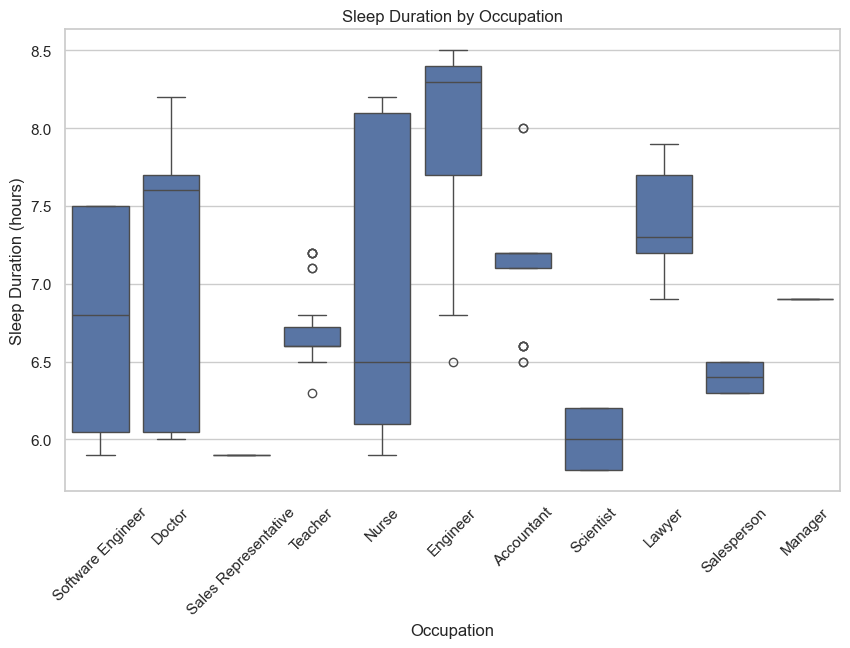

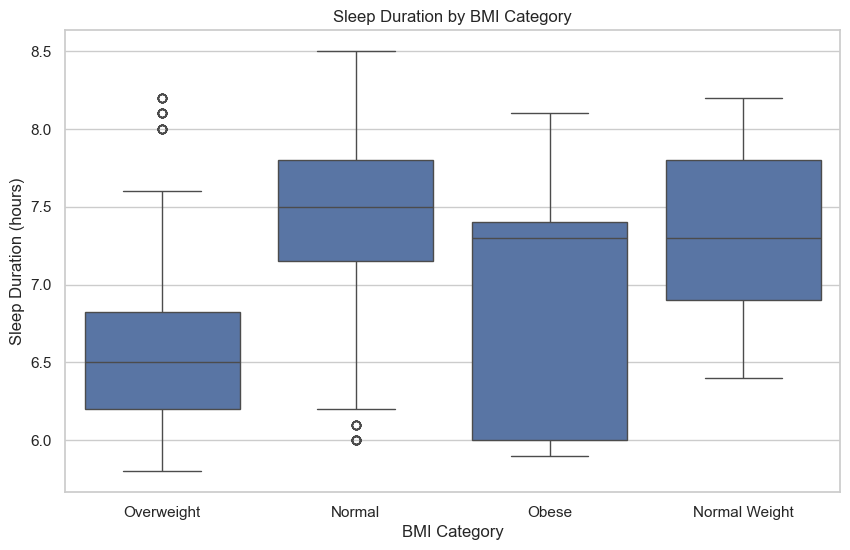

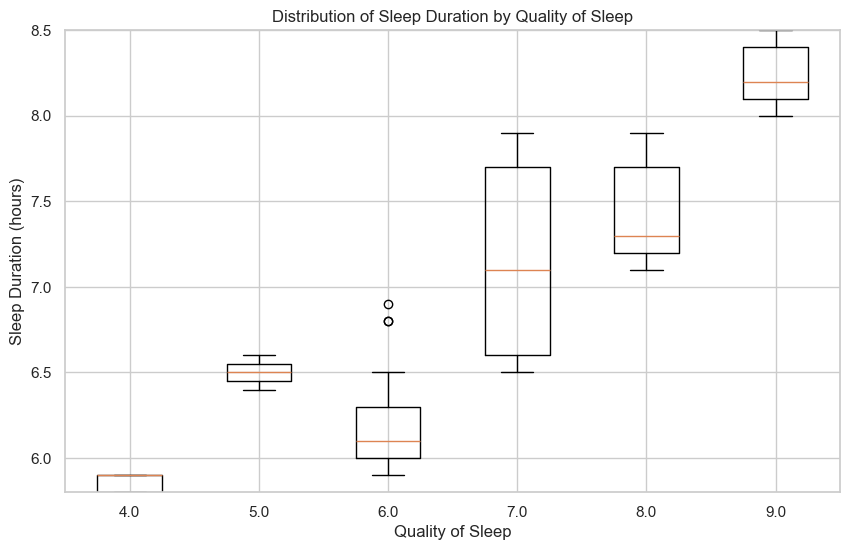

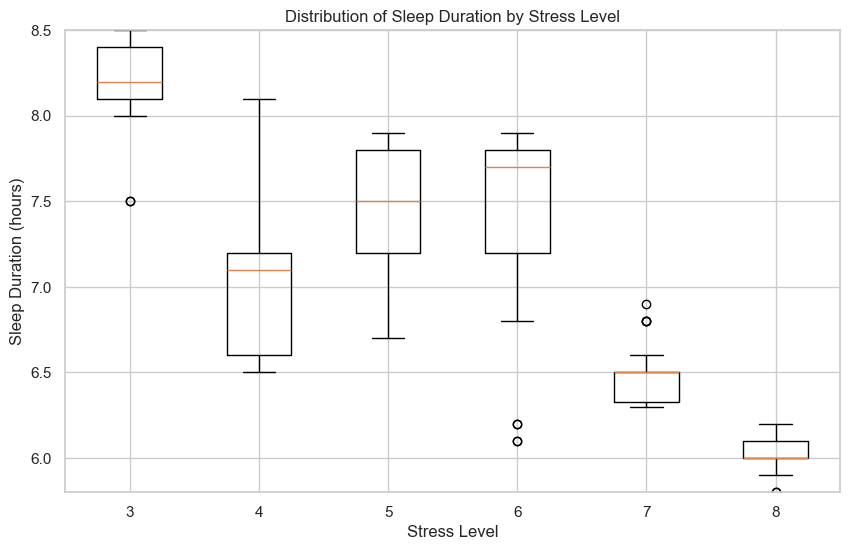

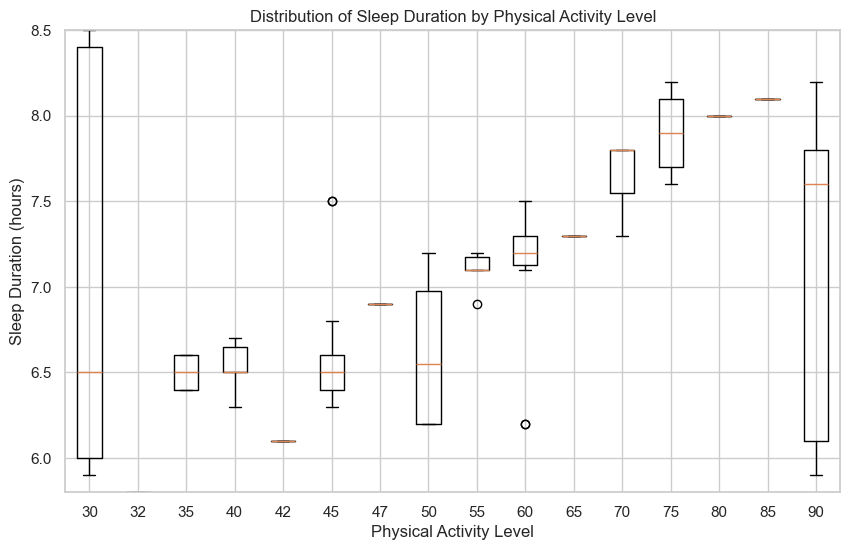

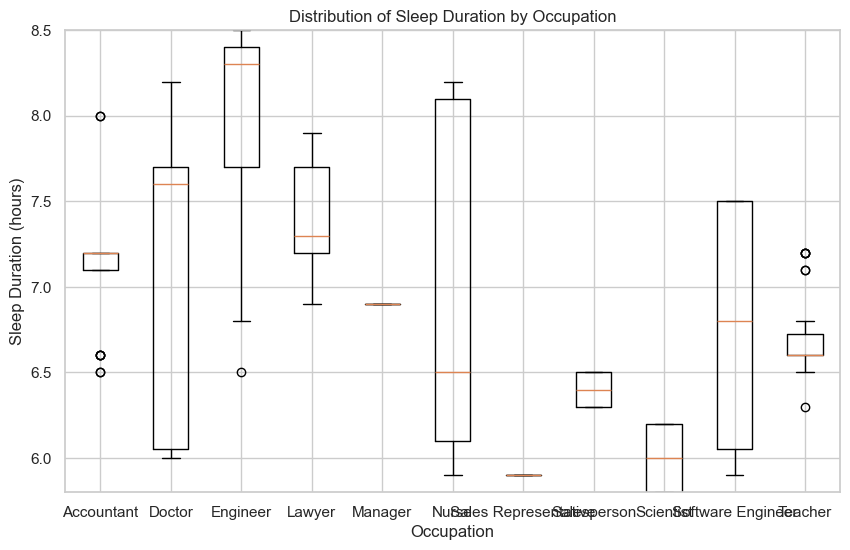

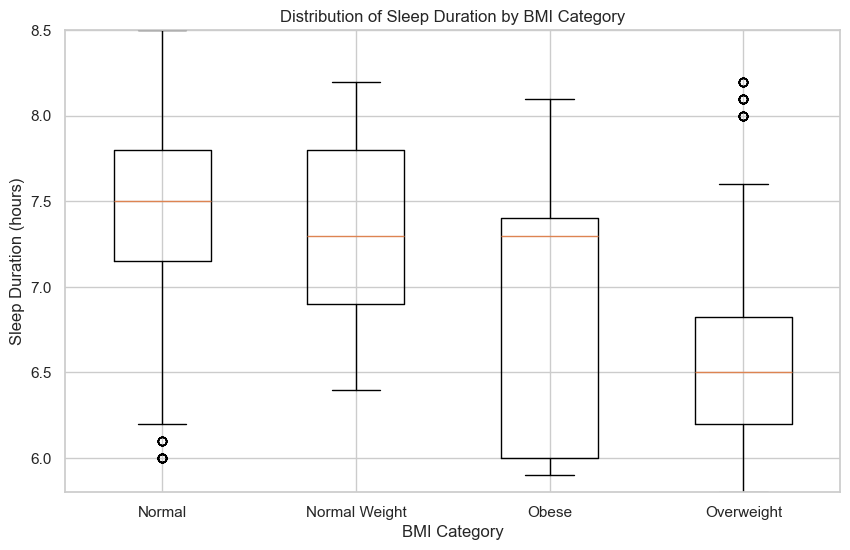

Pandas plotting time: 0.7761778831481934 seconds
NumPy plotting time: 0.6582188606262207 seconds


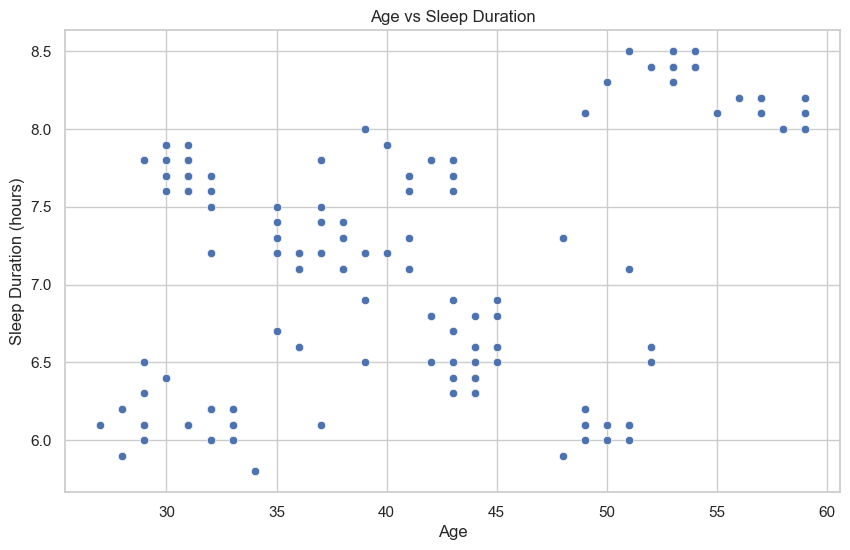

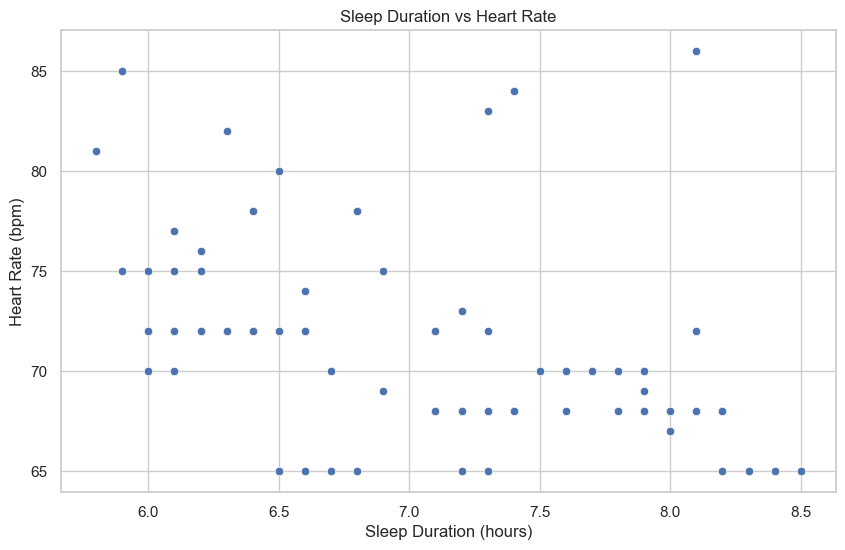

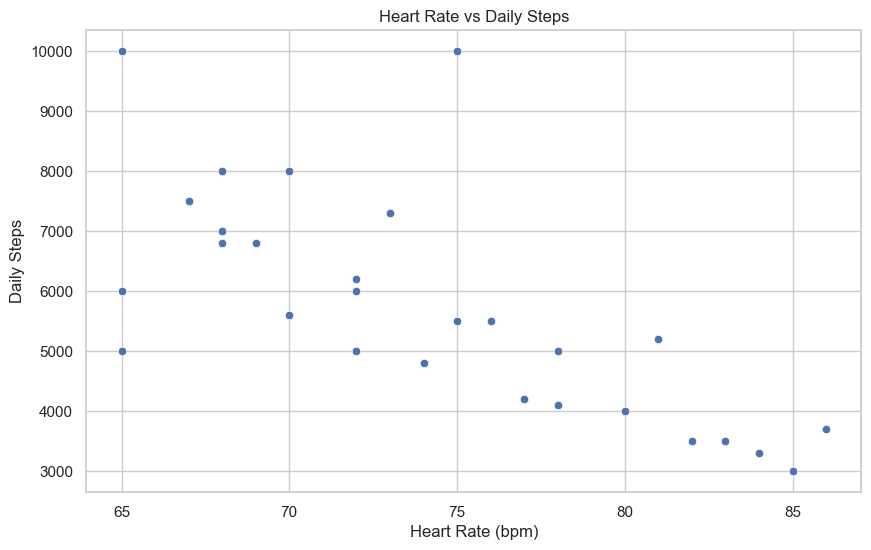

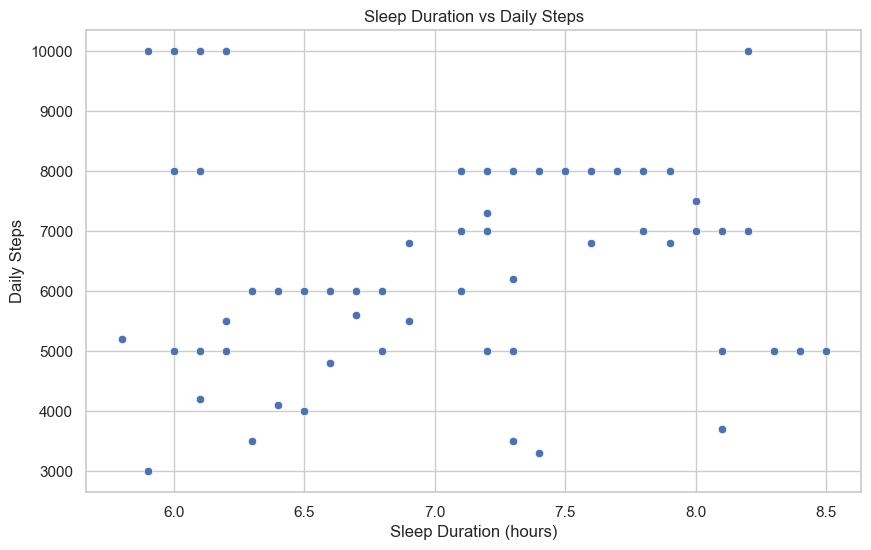

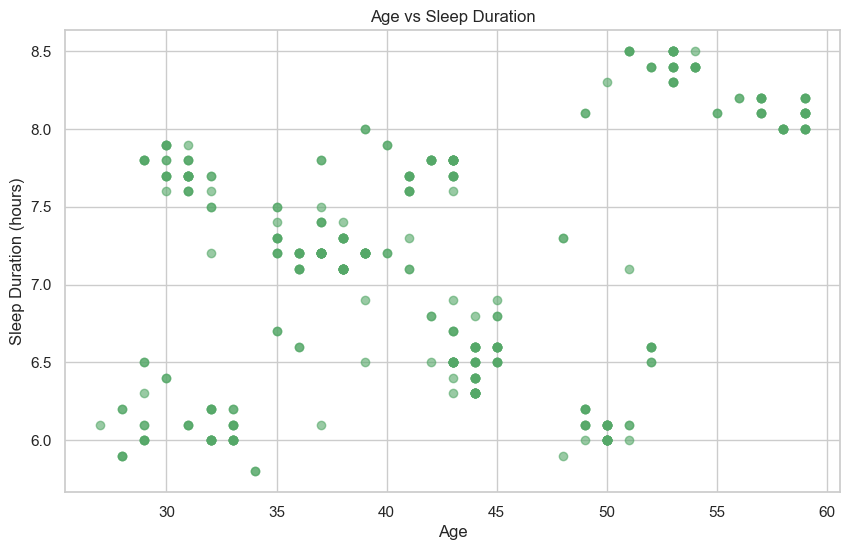

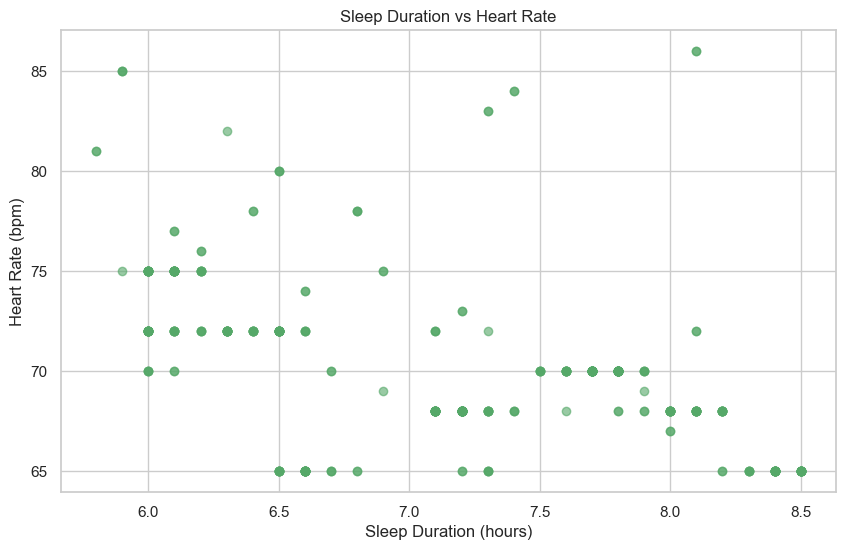

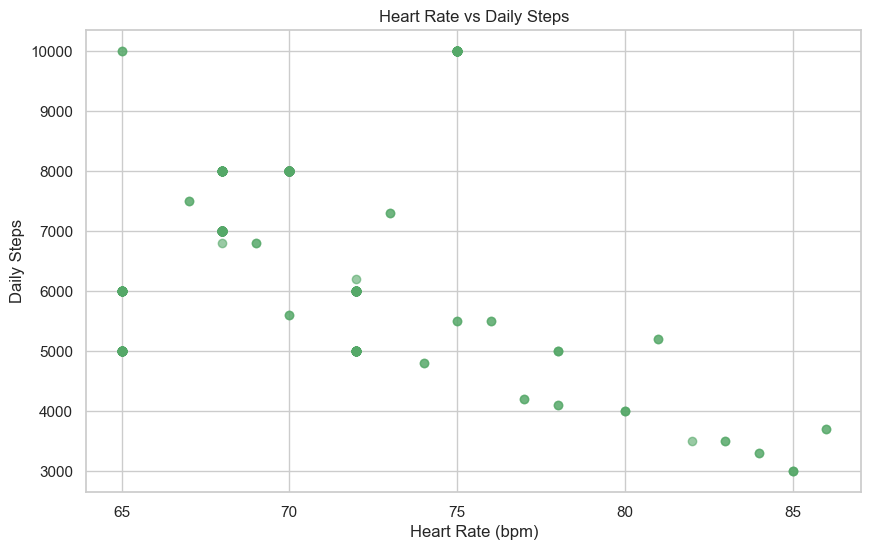

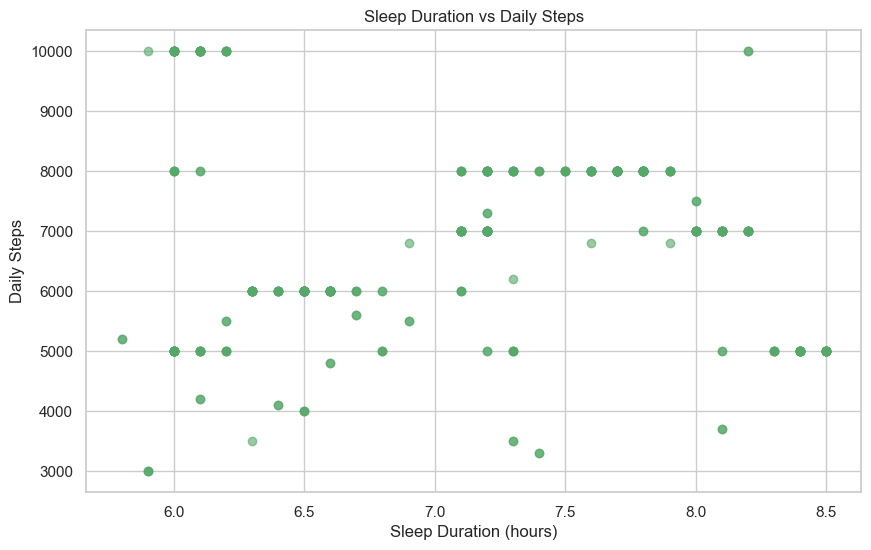

Pandas plotting time: 0.48999500274658203 seconds
NumPy plotting time: 0.5477783679962158 seconds


In [3]:
# Write your code for AIM #3 here



#To count unique values and their total count in a NumPy array, use 
# np.unique(array_name, return_counts=True)--- This will return two values, one is the unique values and the other is the total count of each unique value
# You will need this for plotting bar plots




# For box plots in NumPy you will need to 
# create a list of variable1, grouped by the unique value of some variable2 (nominal or ordinal), 
# Syntax: variable1_list = [variable1[variable2 == i] for i in np.unique(variable2)]

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

# Load the dataset
df = pd.read_csv('sleep_health.csv')

sns.set(style="whitegrid")

# Step 1: Using pandas to plot the distribution
start_time_pandas = time.time()

# 1.1 Age distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['Age'])
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

# 1.2 Sleep Duration distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['Sleep Duration'])
plt.title('Sleep Duration Distribution')
plt.xlabel('Sleep Duration (hours)')
plt.ylabel('Frequency')
plt.show()

# 1.3 Quality of Sleep distribution (need to convert to numeric)
df['Quality of Sleep'] = df['Quality of Sleep'].astype(float)
plt.figure(figsize=(10, 6))
sns.histplot(df['Quality of Sleep'])
plt.title('Quality of Sleep Distribution')
plt.xlabel('Quality of Sleep')
plt.ylabel('Frequency')
plt.show()

# 1.4 Physical Activity Level distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['Physical Activity Level'])
plt.title('Physical Activity Level Distribution')
plt.xlabel('Physical Activity Level')
plt.ylabel('Frequency')
plt.show()

# 1.5 Stress Level distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['Stress Level'])
plt.title('Stress Level Distribution')
plt.xlabel('Stress Level')
plt.ylabel('Frequency')
plt.show()

# 1.6 Heart Rate distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['Heart Rate'])
plt.title('Heart Rate Distribution')
plt.xlabel('Heart Rate (bpm)')
plt.ylabel('Frequency')
plt.show()

end_time_pandas = time.time()

# Step 2: Using NumPy to plot the distribution
start_time_numpy = time.time()

# Convert columns to numpy arrays
age = df['Age'].values
sleep_duration = df['Sleep Duration'].values
quality_of_sleep = df['Quality of Sleep'].astype(float).values
physical_activity_level = df['Physical Activity Level'].values
stress_level = df['Stress Level'].values
heart_rate = df['Heart Rate'].values

# 2.1 Age distribution
plt.figure(figsize=(10, 6))
plt.hist(age, bins=20, density=True, alpha=0.6, color='g')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

# 2.2 Sleep Duration distribution
plt.figure(figsize=(10, 6))
plt.hist(sleep_duration, bins=20, density=True, alpha=0.6, color='g')
plt.title('Sleep Duration Distribution')
plt.xlabel('Sleep Duration (hours)')
plt.ylabel('Frequency')
plt.show()

# 2.3 Quality of Sleep distribution
plt.figure(figsize=(10, 6))
plt.hist(quality_of_sleep, bins=20, density=True, alpha=0.6, color='g')
plt.title('Quality of Sleep Distribution')
plt.xlabel('Quality of Sleep')
plt.ylabel('Frequency')
plt.show()

# 2.4 Physical Activity Level distribution
plt.figure(figsize=(10, 6))
plt.hist(physical_activity_level, bins=20, density=True, alpha=0.6, color='g')
plt.title('Physical Activity Level Distribution')
plt.xlabel('Physical Activity Level')
plt.ylabel('Frequency')
plt.show()

# 2.5 Stress Level distribution
plt.figure(figsize=(10, 6))
plt.hist(stress_level, bins=20, density=True, alpha=0.6, color='g')
plt.title('Stress Level Distribution')
plt.xlabel('Stress Level')
plt.ylabel('Frequency')
plt.show()

# 2.6 Heart Rate distribution
plt.figure(figsize=(10, 6))
plt.hist(heart_rate, bins=20, density=True, alpha=0.6, color='g')
plt.title('Heart Rate Distribution')
plt.xlabel('Heart Rate (bpm)')
plt.ylabel('Frequency')
plt.show()

end_time_numpy = time.time()

# Calculate the time difference for Step 1 and Step 2
print(f"Pandas plotting time: {end_time_pandas - start_time_pandas} seconds")
print(f"NumPy plotting time: {end_time_numpy - start_time_numpy} seconds")

# Step 3: Using pandas to plot the distribution based on categories
start_time_pandas = time.time()

# 3.1 Sleep Duration based on Quality of Sleep
plt.figure(figsize=(10, 6))
sns.boxplot(x='Quality of Sleep', y='Sleep Duration', data=df)
plt.title('Sleep Duration by Quality of Sleep')
plt.xlabel('Quality of Sleep')
plt.ylabel('Sleep Duration (hours)')
plt.show()

# 3.2 Sleep Duration based on Stress Level
plt.figure(figsize=(10, 6))
sns.boxplot(x='Stress Level', y='Sleep Duration', data=df)
plt.title('Sleep Duration by Stress Level')
plt.xlabel('Stress Level')
plt.ylabel('Sleep Duration (hours)')
plt.show()

# 3.3 Sleep Duration based on Physical Activity Level
plt.figure(figsize=(10, 6))
sns.boxplot(x='Physical Activity Level', y='Sleep Duration', data=df)
plt.title('Sleep Duration by Physical Activity Level')
plt.xlabel('Physical Activity Level')
plt.ylabel('Sleep Duration (hours)')
plt.show()

# 3.4 Sleep Duration based on Occupation
plt.figure(figsize=(10, 6))
sns.boxplot(x='Occupation', y='Sleep Duration', data=df)
plt.title('Sleep Duration by Occupation')
plt.xlabel('Occupation')
plt.ylabel('Sleep Duration (hours)')
plt.xticks(rotation=45)
plt.show()

# 3.5 Sleep Duration based on BMI
plt.figure(figsize=(10, 6))
sns.boxplot(x='BMI Category', y='Sleep Duration', data=df)
plt.title('Sleep Duration by BMI Category')
plt.xlabel('BMI Category')
plt.ylabel('Sleep Duration (hours)')
plt.show()

end_time_pandas = time.time()

# Step 4 : Using numpy to plot the distribution based on categories

# Function to create a boxplot for a specific category using NumPy

start_time_numpy = time.time()

def numpy_boxplot(y, x, categories, title, xlabel, ylabel):
    fig, ax = plt.subplots(figsize=(10, 6))
    unique_categories = np.unique(x)
    for i, category in enumerate(unique_categories):
        # Extract the data for the current category
        category_data = y[x == category]
        # Plot the data using a boxplot
        ax.boxplot(category_data, positions=[i + 1], widths=0.5)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_xticks(range(1, len(unique_categories) + 1))
    ax.set_xticklabels([f'{cat}' for cat in unique_categories])
    ax.set_ylim(y.min(), y.max())
    plt.show()

# Assuming the dataframe 'df' has been loaded and necessary columns are numeric
sleep_duration = df['Sleep Duration'].values
quality_of_sleep = df['Quality of Sleep'].values.astype(float)
stress_level = df['Stress Level'].values
physical_activity_level = df['Physical Activity Level'].values
occupation = df['Occupation'].values
bmi_category = df['BMI Category'].values

# 4.1 Sleep Duration based on Quality of Sleep
numpy_boxplot(sleep_duration, quality_of_sleep, np.unique(quality_of_sleep).astype(str), 'Distribution of Sleep Duration by Quality of Sleep', 'Quality of Sleep', 'Sleep Duration (hours)')

# 4.2 Sleep Duration based on Stress Level
numpy_boxplot(sleep_duration, stress_level, np.unique(stress_level).astype(str), 'Distribution of Sleep Duration by Stress Level', 'Stress Level', 'Sleep Duration (hours)')

# 4.3 Sleep Duration based on Physical Activity Level
numpy_boxplot(sleep_duration, physical_activity_level, np.unique(physical_activity_level).astype(str), 'Distribution of Sleep Duration by Physical Activity Level', 'Physical Activity Level', 'Sleep Duration (hours)')

# 4.4 Sleep Duration based on Occupation
numpy_boxplot(sleep_duration, occupation, np.unique(occupation), 'Distribution of Sleep Duration by Occupation', 'Occupation', 'Sleep Duration (hours)')

# 4.5 Sleep Duration based on BMI
numpy_boxplot(sleep_duration, bmi_category, np.unique(bmi_category), 'Distribution of Sleep Duration by BMI Category', 'BMI Category', 'Sleep Duration (hours)')
end_time_numpy = time.time()

# Calculate the time difference for Step 1 and Step 2
print(f"Pandas plotting time: {end_time_pandas - start_time_pandas} seconds")
print(f"NumPy plotting time: {end_time_numpy - start_time_numpy} seconds")


# Step 5: Using pandas to plot the relation between variables
start_time_pandas = time.time()

# 5.1 Age and Sleep Duration
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Age', y='Sleep Duration', data=df)
plt.title('Age vs Sleep Duration')
plt.xlabel('Age')
plt.ylabel('Sleep Duration (hours)')
plt.show()

# 5.2 Sleep Duration and Heart Rate
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Sleep Duration', y='Heart Rate', data=df)
plt.title('Sleep Duration vs Heart Rate')
plt.xlabel('Sleep Duration (hours)')
plt.ylabel('Heart Rate (bpm)')
plt.show()

# 5.3 Heart Rate and Daily Steps
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Heart Rate', y='Daily Steps', data=df)
plt.title('Heart Rate vs Daily Steps')
plt.xlabel('Heart Rate (bpm)')
plt.ylabel('Daily Steps')
plt.show()

# 5.4 Sleep Duration and Daily Steps
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Sleep Duration', y='Daily Steps', data=df)
plt.title('Sleep Duration vs Daily Steps')
plt.xlabel('Sleep Duration (hours)')
plt.ylabel('Daily Steps')
plt.show()

end_time_pandas = time.time()

# Step 6: Using NumPy to plot relationships between variables

# 6.1 Age and Sleep Duration

start_time_numpy = time.time()

plt.figure(figsize=(10, 6))
plt.scatter(age, sleep_duration, alpha=0.6, color='g')
plt.title('Age vs Sleep Duration')
plt.xlabel('Age')
plt.ylabel('Sleep Duration (hours)')
plt.show()

# 6.2 Sleep Duration and Heart Rate
plt.figure(figsize=(10, 6))
plt.scatter(sleep_duration, heart_rate, alpha=0.6, color='g')
plt.title('Sleep Duration vs Heart Rate')
plt.xlabel('Sleep Duration (hours)')
plt.ylabel('Heart Rate (bpm)')
plt.show()

# 6.3 Heart Rate and Daily Steps
plt.figure(figsize=(10, 6))
plt.scatter(heart_rate, df['Daily Steps'].values, alpha=0.6, color='g')
plt.title('Heart Rate vs Daily Steps')
plt.xlabel('Heart Rate (bpm)')
plt.ylabel('Daily Steps')
plt.show()

# 6.4 Sleep Duration and Daily Steps
plt.figure(figsize=(10, 6))
plt.scatter(sleep_duration, df['Daily Steps'].values, alpha=0.6, color='g')
plt.title('Sleep Duration vs Daily Steps')
plt.xlabel('Sleep Duration (hours)')
plt.ylabel('Daily Steps')
plt.show()

end_time_numpy = time.time()



# Calculate the time difference for Step 1 and Step 2
print(f"Pandas plotting time: {end_time_pandas - start_time_pandas} seconds")
print(f"NumPy plotting time: {end_time_numpy - start_time_numpy} seconds")

AIM #4: Other possible plotting

1. Think of other possible plots to show some interesting distribution and relations. Do this using both pandas and NumPy



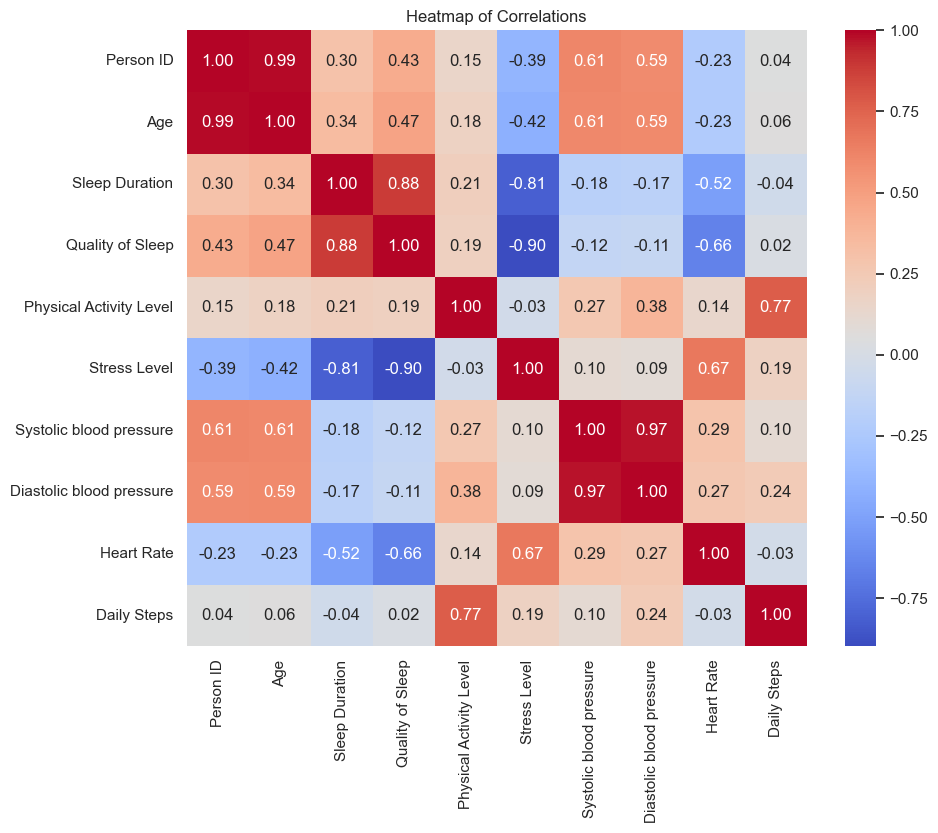

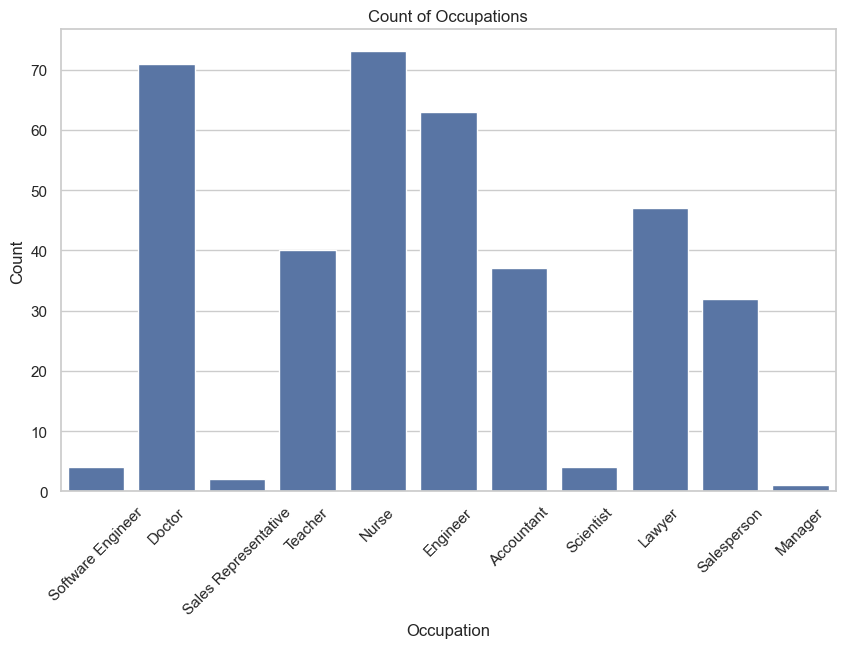

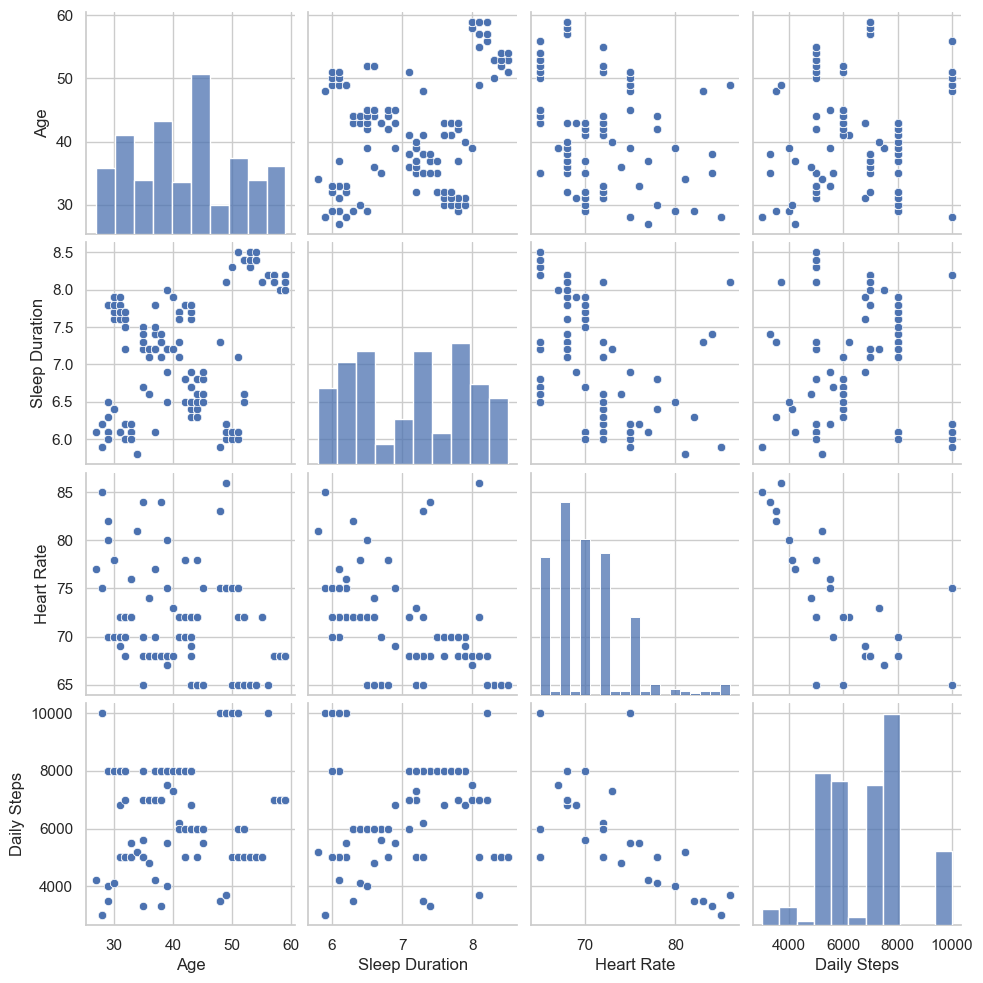

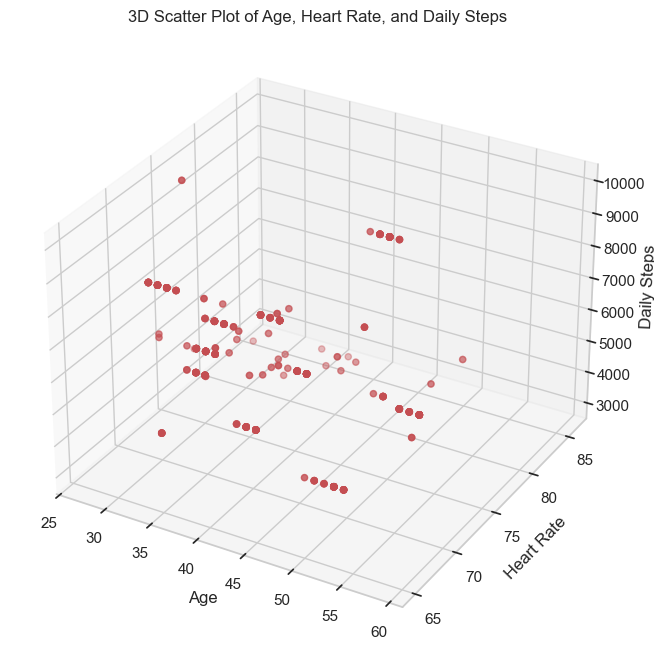

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

# Load the dataset
df = pd.read_csv('sleep_health.csv')

# Convert 'Quality of Sleep' to numeric if it's not already
df['Quality of Sleep'] = df['Quality of Sleep'].astype(float)

# Set the style for seaborn plots
sns.set(style="whitegrid")

# Filter the dataframe to include only numeric columns for correlation
numeric_df = df.select_dtypes(include=[np.number])

# Using pandas to plot a heatmap of correlations
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Heatmap of Correlations')
plt.show()

# Using pandas to plot a count plot of 'Occupation'
plt.figure(figsize=(10, 6))
sns.countplot(x='Occupation', data=df)
plt.title('Count of Occupations')
plt.xlabel('Occupation')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

# Using pandas to plot a pair plot
sns.pairplot(df[['Age', 'Sleep Duration', 'Heart Rate', 'Daily Steps']])
plt.show()

# Using NumPy and matplotlib to plot a 3D scatter plot of 'Age', 'Heart Rate', and 'Daily Steps'
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df['Age'], df['Heart Rate'], df['Daily Steps'], c='r', marker='o')
ax.set_title('3D Scatter Plot of Age, Heart Rate, and Daily Steps')
ax.set_xlabel('Age')
ax.set_ylabel('Heart Rate')
ax.set_zlabel('Daily Steps')
plt.show()